# BTC Price Forecasting — ARIMA + MSTL Model


In [1]:
!pip install statsforecast pmdarima -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.6 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsforecast import StatsForecast
from statsforecast.models import MSTL

plt.rcParams.update({
    'figure.facecolor': '#0a0a0f',
    'axes.facecolor':   '#12121f',
    'axes.edgecolor':   '#f7931a44',
    'axes.labelcolor':  '#e8e8f0',
    'xtick.color':      '#e8e8f0',
    'ytick.color':      '#e8e8f0',
    'text.color':       '#e8e8f0',
    'grid.color':       '#1e1e2e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})
print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Load & Parse Data

In [3]:
CSV_PATH = '/content/bitcoin_price_2015_2025.csv'

raw_df = pd.read_csv(CSV_PATH)
raw_df.columns = [c.strip() for c in raw_df.columns]
print('Columns:', raw_df.columns.tolist())
raw_df.head()

Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


,Date,Close,High,Low,Open,Volume
0,NaN,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,2015-01-01,314.2489929199219,320.43499755859375,314.00299072265625,320.43499755859375,8036550
2,2015-01-02,315.0320129394531,315.8389892578125,313.56500244140625,314.0790100097656,7860650
3,2015-01-03,281.0820007324219,315.1499938964844,281.0820007324219,314.84600830078125,33054400
4,2015-01-04,264.19500732421875,287.2300109863281,257.61199951171875,281.14599609375,55629100


In [4]:
date_candidates = [c for c in raw_df.columns
    if any(k in c.lower() for k in ['date', 'time', 'timestamp'])
]
price_candidates = [c for c in raw_df.columns
    if any(k in c.lower() for k in ['close', 'open', 'high', 'low', 'price'])
]

if not date_candidates or not price_candidates:
    raise ValueError("Could not detect date or price column")

date_col  = next((c for c in date_candidates if 'date' in c.lower()), date_candidates[0])
price_col = next((c for c in price_candidates if 'close' in c.lower()), price_candidates[0])

print(f'Using date column  : {date_col}')
print(f'Using price column : {price_col}')

df = raw_df[[date_col, price_col]].copy()
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

if df[price_col].dtype == object:
    df[price_col] = (
        df[price_col].astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
        .str.strip()
    )
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
df = df.dropna().sort_values(date_col).reset_index(drop=True)
df = df.rename(columns={date_col: 'Date', price_col: 'Close'})
df = df.set_index('Date')

time_diff = df.index.to_series().diff().median()
if time_diff < pd.Timedelta(days=1):
    df = df.resample('D').last().dropna()

price_series = df.reset_index()
price_series.columns = ['ds', 'y']
price_series = price_series.drop_duplicates('ds').sort_values('ds').reset_index(drop=True)
print(f'\nDate range : {price_series.ds.min().date()} → {price_series.ds.max().date()}')
print(f'Total rows : {len(price_series):,}')
price_series.tail()

Using date column  : Date
Using price column : Close

Date range : 2015-01-01 → 2025-09-16
Total rows : 3,912


,ds,y
3907,2025-09-12,116101.578125
3908,2025-09-13,115950.507812
3909,2025-09-14,115407.656250
3910,2025-09-15,115444.875000
3911,2025-09-16,116843.187500


## 2 · Exploratory Analysis

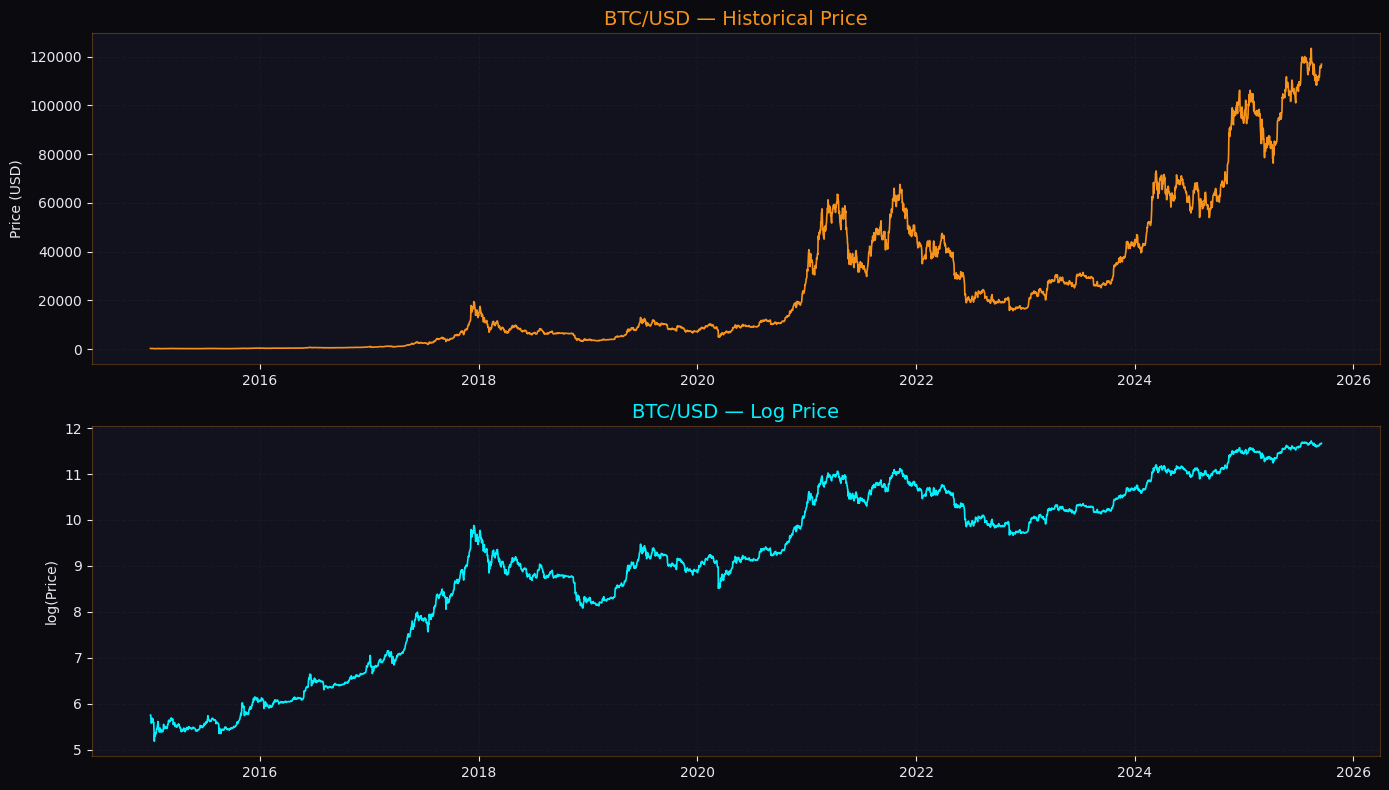

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(price_series['ds'], price_series['y'], color='#f7931a', linewidth=1.2)
axes[0].set_title('BTC/USD — Historical Price', fontsize=14, color='#f7931a')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True)

log_series = np.log(price_series['y'])
axes[1].plot(price_series['ds'], log_series, color='#00f2ff', linewidth=1.2)
axes[1].set_title('BTC/USD — Log Price', fontsize=14, color='#00f2ff')
axes[1].set_ylabel('log(Price)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3 · Stationarity Check (ADF Test)

In [6]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"{'='*40}")
    print(f"ADF Test — {label}")
    print(f"  Statistic : {result[0]:.4f}")
    print(f"  p-value   : {result[1]:.4f}")
    conclusion = 'Stationary ✓' if result[1] < 0.05 else 'Non-stationary ✗'
    print(f"  Result    : {conclusion}")

log_series = np.log(price_series['y'])
diff_log   = log_series.diff().dropna()

adf_report(log_series, 'Log Price')
adf_report(diff_log,   'First-differenced Log Price')

ADF Test — Log Price
  Statistic : -1.1329
  p-value   : 0.7018
  Result    : Non-stationary ✗
ADF Test — First-differenced Log Price
  Statistic : -64.2107
  p-value   : 0.0000
  Result    : Stationary ✓


## 4 · ACF / PACF — Diagnose ARIMA Order on Raw Series

We run ACF/PACF on the first-differenced log-price to understand the raw series structure. Note: after MSTL decomposition in Section 5b the remainder is already stationary, so the actual ARIMA fitted in Section 6 uses `d=0`. The order `p` is confirmed in Section 6 by an ADF check + `auto_arima` on the MSTL remainder directly.

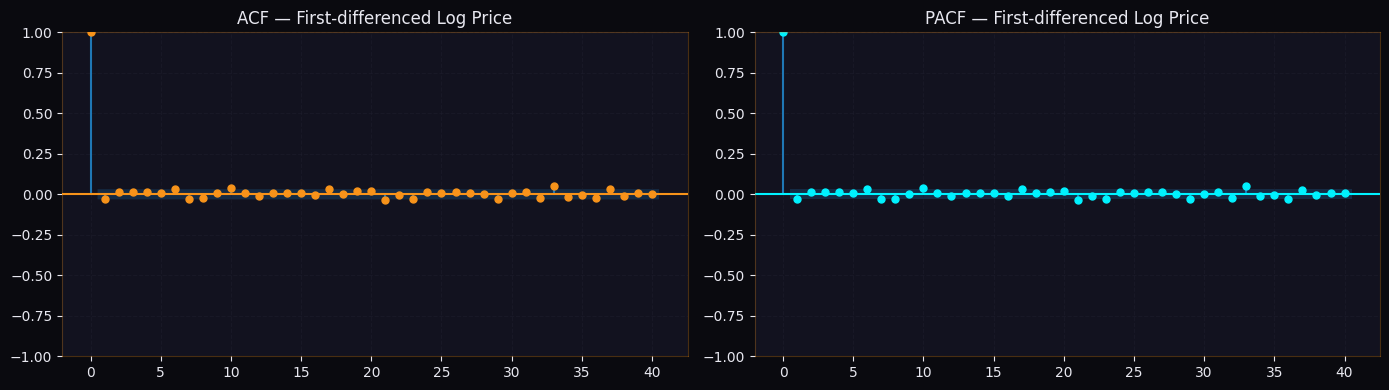

ACF/PACF on raw series for reference — final order selected by auto_arima on MSTL remainder (Section 6).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_log,  lags=40, ax=axes[0], color='#f7931a',
         title='ACF — First-differenced Log Price')
plot_pacf(diff_log, lags=40, ax=axes[1], color='#00f2ff',
          title='PACF — First-differenced Log Price')
for ax in axes:
    ax.set_facecolor('#12121f')
    ax.grid(True)

plt.tight_layout()
plt.show()


## 5 · Train / Test Split

In [8]:
TEST_RATIO = 0.10
split = int(len(price_series) * (1 - TEST_RATIO))

train = price_series.iloc[:split].copy()
test  = price_series.iloc[split:].copy()

print(f'Train : {len(train):,} rows  ({train["ds"].iloc[0].date()} → {train["ds"].iloc[-1].date()})')
print(f'Test  : {len(test):,}  rows  ({test["ds"].iloc[0].date()} → {test["ds"].iloc[-1].date()})')

Train : 3,520 rows  (2015-01-01 → 2024-08-20)
Test  : 392  rows  (2024-08-21 → 2025-09-16)


MSTL decomposition components: ['data', 'trend', 'seasonal7', 'seasonal30', 'seasonal90', 'seasonal365', 'remainder', 'ds']


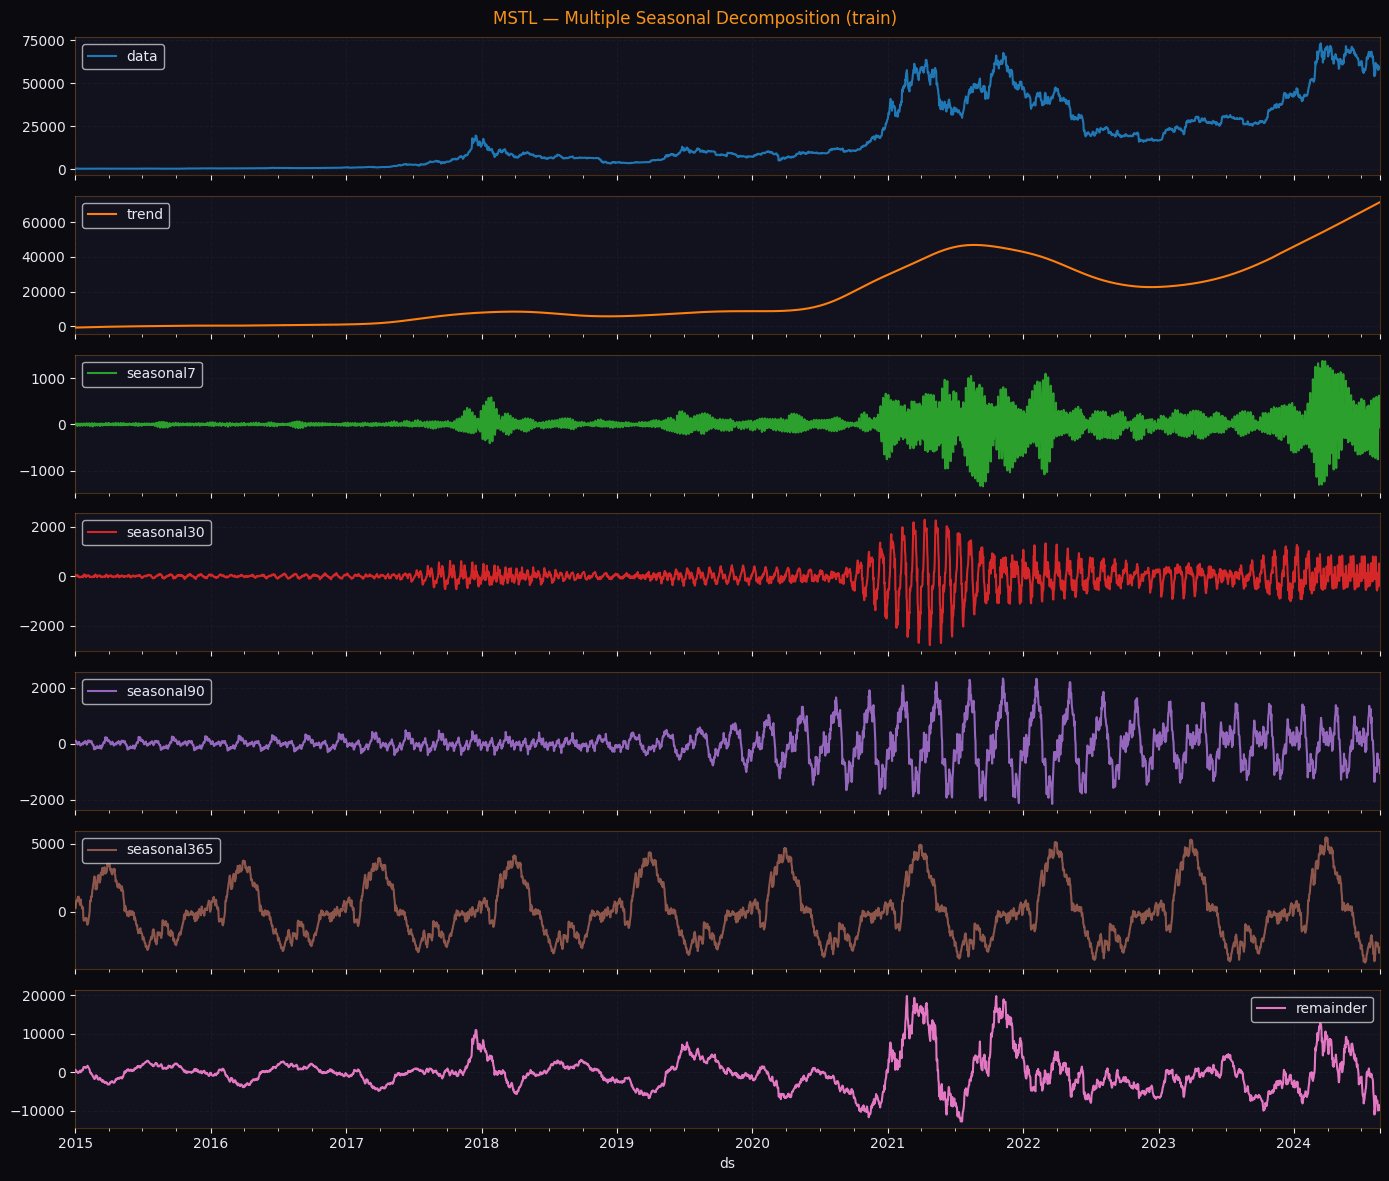

In [9]:
# ── 5b · MSTL Multiple Seasonality Decomposition on TRAIN ────────────────────

train_sf = pd.DataFrame({
    'ds':        train['ds'],
    'y':         train['y'],
    'unique_id': 'btc'
})

mstl_pipeline = StatsForecast(
    models=[MSTL(season_length=[7, 30, 90, 365])],
    freq='D',
    n_jobs=-1
)
mstl_pipeline.fit(train_sf)

decompose_data = mstl_pipeline.fitted_[0, 0].model_.copy()
decompose_data['ds'] = train['ds'].values

print("MSTL decomposition components:", decompose_data.columns.tolist())
decompose_data.plot(x='ds', subplots=True, grid=True, figsize=(14, 12))
plt.suptitle('MSTL — Multiple Seasonal Decomposition (train)', color='#f7931a')
plt.tight_layout()
plt.show()

## 6 · Select ARIMA Order on MSTL Remainder



ADF on MSTL remainder — p-value: 0.0000
Remainder is stationary ✓ → d=0 justified


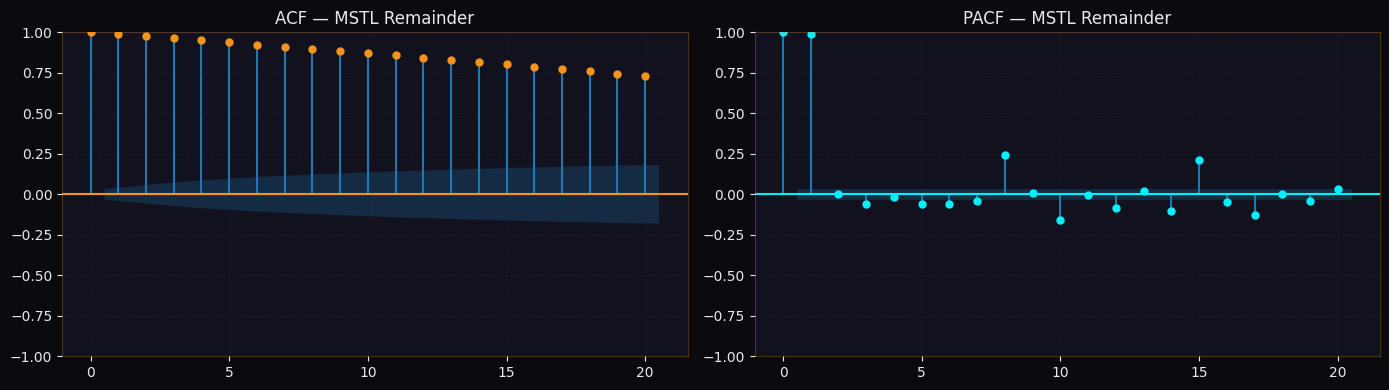

In [10]:
# ── Extract MSTL remainder (stationary residuals) ────────────────────────────
remainder = decompose_data['remainder'].values
remainder_series = pd.Series(remainder, index=train['ds'].values).dropna()

# ADF on remainder — expect stationary (p < 0.05) so d=0 is justified
adf_result = adfuller(remainder_series.dropna())
print(f"ADF on MSTL remainder — p-value: {adf_result[1]:.4f}")
print("Remainder is stationary ✓ → d=0 justified" if adf_result[1] < 0.05
      else "Still non-stationary ✗ → consider d=1")

# ── ACF/PACF on remainder to select p ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(remainder_series.dropna(),  lags=20, ax=axes[0], color='#f7931a',
         title='ACF — MSTL Remainder')
plot_pacf(remainder_series.dropna(), lags=20, ax=axes[1], color='#00f2ff',
          title='PACF — MSTL Remainder')
for ax in axes:
    ax.set_facecolor('#12121f')
    ax.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# ── auto_arima on remainder to confirm order ─────────────────────────────────
from pmdarima import auto_arima as pm_auto_arima

auto_result = pm_auto_arima(
    remainder_series.dropna(),
    d=0,
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
)
print(f"\nauto_arima selected order: {auto_result.order}")
BACKTEST_ORDER = auto_result.order
print(f"Using ARIMA{BACKTEST_ORDER} for backtest path")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=55991.685, Time=1.58 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=69487.122, Time=0.17 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=56006.816, Time=0.14 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=65353.636, Time=1.43 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=56000.293, Time=0.35 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=56004.745, Time=0.85 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=6.77 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=55978.520, Time=2.93 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=56001.421, Time=0.37 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=5.54 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=55976.850, Time=3.17 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=55981.883, Time=0.71 sec
 ARIMA(3,0,4)(0,0,0)[0]             : AIC=inf, Time=4.38 sec
 ARIMA(2,0,5)(0,0,0)[0]             : AIC=55965.065, Time=2.28 sec
 ARIMA(1,0,5)(0,0,0)[0]             :

In [12]:
# ── Fit selected order on train remainder ────────────────────────────────────
arima_model = SARIMAX(
    remainder_series.dropna(),
    order=BACKTEST_ORDER,
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_fitted = arima_model.fit(disp=False)
print(arima_fitted.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3520
Model:               SARIMAX(1, 0, 5)   Log Likelihood              -27927.935
Date:                Thu, 23 Apr 2026   AIC                          55869.870
Time:                        22:18:56   BIC                          55913.022
Sample:                    01-01-2015   HQIC                         55885.268
                         - 08-20-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9822      0.002    468.625      0.000       0.978       0.986
ma.L1         -0.0049      0.010     -0.481      0.630      -0.025       0.015
ma.L2          0.1064      0.010     10.816      0.0

## 7 · Backtest on Test Set


MSTL + ARIMA  MAE  : $23,704.83
MSTL + ARIMA  RMSE : $28,209.37
MSTL + ARIMA  MAPE : 23.11%


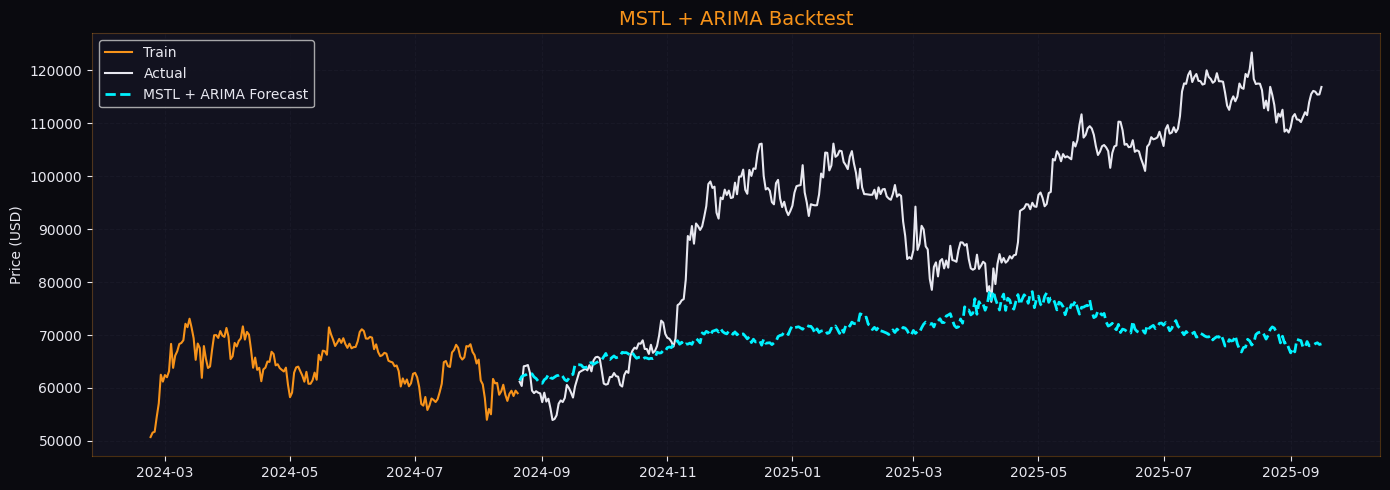

In [13]:
# ── Forecast ARIMA residuals over test horizon ───────────────────────────────
fc_result = arima_fitted.get_forecast(steps=len(test))
arima_fc  = fc_result.predicted_mean.values
arima_ci  = fc_result.conf_int(alpha=0.05)

last_trend    = decompose_data['trend'].dropna().iloc[-1]
seasonal_cols = [c for c in decompose_data.columns if 'seasonal' in c.lower()]
tile_window  = max(365, len(test))
last_cycle   = decompose_data[seasonal_cols].iloc[-tile_window:].values
repeat_n     = int(np.ceil(len(test) / len(last_cycle))) + 1
tiled        = np.tile(last_cycle, (repeat_n, 1))[:len(test)]
seasonal_sum = tiled.sum(axis=1)

fc_combined = last_trend + seasonal_sum + arima_fc[:len(test)]

y_true = test['y'].values[:len(fc_combined)]
mae  = np.mean(np.abs(y_true - fc_combined))
rmse = np.sqrt(np.mean((y_true - fc_combined) ** 2))
mape = np.mean(np.abs((y_true - fc_combined) / y_true)) * 100

print(f'MSTL + ARIMA  MAE  : ${mae:,.2f}')
print(f'MSTL + ARIMA  RMSE : ${rmse:,.2f}')
print(f'MSTL + ARIMA  MAPE : {mape:.2f}%')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.iloc[-180:]['ds'], train.iloc[-180:]['y'],
        color='#f7931a', linewidth=1.5, label='Train')
ax.plot(test['ds'], test['y'],
        color='#e8e8f0', linewidth=1.5, label='Actual')
ax.plot(test['ds'].values[:len(fc_combined)], fc_combined,
        color='#00f2ff', linewidth=2, linestyle='--', label='MSTL + ARIMA Forecast')
ax.set_title('MSTL + ARIMA Backtest', fontsize=14, color='#f7931a')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 8 · Future Forecast


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Forecast start : 2025-09-17
Forecast end   : 2025-10-16

Day 1   forecast : $117,982.16
Day 30  forecast : $117,671.18


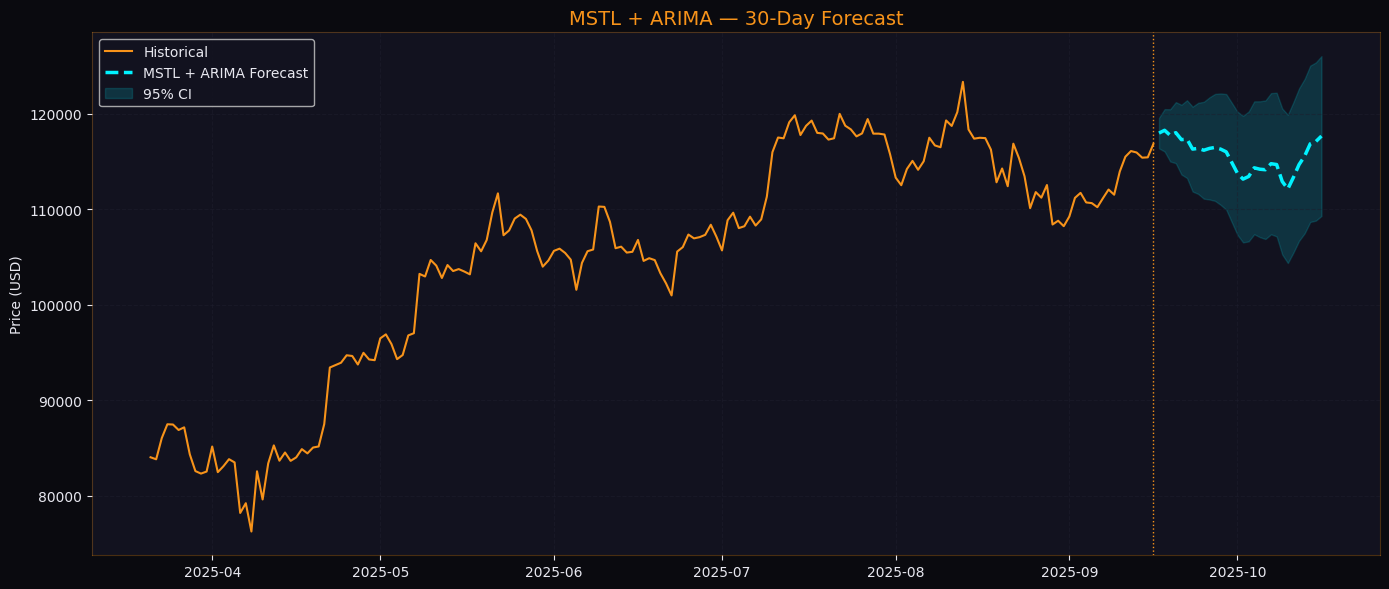

In [19]:
CI      = 0.95
HORIZON = 30
# d=0 because MSTL already removed the trend (remainder is stationary).
FULL_FORECAST_ORDER = (1, 0, 5)

# ── 1. Full series for MSTL ───────────────────────────────────────────────────
price_full = pd.to_numeric(df['Close'], errors='coerce').dropna()

full_sf = pd.DataFrame({
    'ds':        price_full.index,
    'y':         price_full.values,
    'unique_id': 'btc'
})

# ── 2. MSTL on full series ────────────────────────────────────────────────────
mstl_full = StatsForecast(
    models=[MSTL(season_length=[7, 30, 90, 365])],
    freq='D',
    n_jobs=-1
)
mstl_full.fit(full_sf)

decompose_full = mstl_full.fitted_[0, 0].model_.copy()
decompose_full['ds'] = price_full.index

# ── 3. Fit ARIMA(4,0,0) on full remainder ────────────────────────────────────
remainder_full = pd.Series(
    decompose_full['remainder'].values,
    index=price_full.index
).dropna()

arima_full = SARIMAX(
    remainder_full,
    order=FULL_FORECAST_ORDER,
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_full_fitted = arima_full.fit(disp=False)

# ── 4. Forecast residuals ─────────────────────────────────────────────────────
future_result = arima_full_fitted.get_forecast(steps=HORIZON)
future_ci     = future_result.conf_int(alpha=1 - CI)
arima_fc_f    = future_result.predicted_mean.values
arima_lo      = future_ci.iloc[:, 0].values
arima_hi      = future_ci.iloc[:, 1].values

future_dates = pd.date_range(
    start=price_full.index[-1] + timedelta(days=1),
    periods=HORIZON
)

# ── 5. Recompose: trend + seasonal + ARIMA residual ──────────────────────────
last_trend_f    = decompose_full['trend'].dropna().iloc[-1]
seasonal_cols_f = [c for c in decompose_full.columns if 'seasonal' in c.lower()]

tile_window_f       = max(365, HORIZON)
last_cycle_f        = decompose_full[seasonal_cols_f].iloc[-tile_window_f:].values
repeat_n_f          = int(np.ceil(HORIZON / len(last_cycle_f))) + 1
tiled_f             = np.tile(last_cycle_f, (repeat_n_f, 1))[:HORIZON]
seasonal_projection = tiled_f.sum(axis=1)

future_mean = last_trend_f + seasonal_projection + arima_fc_f
future_lo   = last_trend_f + seasonal_projection + arima_lo
future_hi   = last_trend_f + seasonal_projection + arima_hi

print(f"Forecast start : {future_dates[0].date()}")
print(f"Forecast end   : {future_dates[-1].date()}")
print(f"\nDay 1   forecast : ${future_mean[0]:,.2f}")
print(f"Day {HORIZON}  forecast : ${future_mean[-1]:,.2f}")

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(price_full.iloc[-180:].index, price_full.iloc[-180:].values,
        color='#f7931a', linewidth=1.5, label='Historical')
ax.plot(future_dates, future_mean,
        color='#00f2ff', linewidth=2.5, linestyle='--', label='MSTL + ARIMA Forecast')
ax.fill_between(future_dates, future_lo, future_hi,
                alpha=0.15, color='#00f2ff', label=f'{int(CI*100)}% CI')
ax.axvline(price_full.index[-1], color='#f7931a', linewidth=1, linestyle=':')
ax.set_title(f'MSTL + ARIMA — {HORIZON}-Day Forecast', fontsize=14, color='#f7931a')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 9 · Forecast Table

In [20]:
fc_table = pd.DataFrame({
    'Date':                       future_dates.strftime('%Y-%m-%d'),
    'Forecast ($)':               future_mean.round(2),
    f'Lower {int(CI*100)}% ($)':  future_lo.round(2),
    f'Upper {int(CI*100)}% ($)':  future_hi.round(2),
})

fc_table.style.format({
    'Forecast ($)':                   '${:,.2f}',
    f'Lower {int(CI*100)}% ($)':      '${:,.2f}',
    f'Upper {int(CI*100)}% ($)':      '${:,.2f}',
})

,Date,Forecast ($),Lower 95% ($),Upper 95% ($)
0,2025-09-17,"$117,982.16","$116,380.02","$119,584.30"
1,2025-09-18,"$118,275.49","$116,058.98","$120,492.00"
2,2025-09-19,"$117,746.04","$115,011.70","$120,480.39"
3,2025-09-20,"$118,027.24","$114,830.41","$121,224.07"
4,2025-09-21,"$117,296.66","$113,646.27","$120,947.05"
5,2025-09-22,"$117,349.57","$113,278.55","$121,420.58"
6,2025-09-23,"$116,305.62","$111,865.08","$120,746.17"
7,2025-09-24,"$116,382.57","$111,611.37","$121,153.77"
8,2025-09-25,"$116,185.53","$111,114.63","$121,256.43"
9,2025-09-26,"$116,376.72","$111,031.57","$121,721.86"


## 10 · Walk-Forward Validation


In [16]:
import time
seasonal_cols_bt = [c for c in decompose_data.columns if 'seasonal' in c.lower()]
tile_window_bt   = max(365, len(test))
last_cycle_bt    = decompose_data[seasonal_cols_bt].iloc[-tile_window_bt:].values

# Build seasonal projection for each test step
repeat_n_bt   = int(np.ceil(len(test) / len(last_cycle_bt))) + 1
tiled_bt      = np.tile(last_cycle_bt, (repeat_n_bt, 1))[:len(test)]
seasonal_wf   = tiled_bt.sum(axis=1)
trend_wf      = decompose_data['trend'].dropna().iloc[-1]
actual_remainders = test['y'].values - trend_wf - seasonal_wf
# Seed walk-forward history with train remainder
wf_history = list(remainder_series.dropna().values)
predictions_usd = []
test_dates      = test['ds'].values

print(f"Walk-forward over {len(test)} steps (ARIMA on MSTL remainder)...")
start = time.time()

for t in range(len(test)):
    model_wf = SARIMAX(
        wf_history,
        order=BACKTEST_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit_wf = model_wf.fit(disp=False)
    # 1-step ahead residual forecast
    resid_hat = fit_wf.forecast(steps=1)[0]

    # Recompose to USD: trend + seasonal(t) + residual
    usd_hat = trend_wf + seasonal_wf[t] + resid_hat
    predictions_usd.append(usd_hat)

    # Append the ACTUAL remainder (not the forecast) to history
    wf_history.append(actual_remainders[t])

    if (t + 1) % 50 == 0:
        print(f"  {t + 1}/{len(test)} steps done...")

print(f"Finished in {time.time() - start:.1f}s")

wf_df = pd.DataFrame({
    'ds':       test_dates,
    'actual':   test['y'].values,
    'forecast': predictions_usd,
})

Walk-forward over 392 steps (ARIMA on MSTL remainder)...
  50/392 steps done...
  100/392 steps done...
  150/392 steps done...
  200/392 steps done...
  250/392 steps done...
  300/392 steps done...
  350/392 steps done...
Finished in 360.8s


In [17]:
# ── Evaluate walk-forward ─────────────────────────────────────────────────────
wf_mae  = np.mean(np.abs(wf_df['actual'] - wf_df['forecast']))
wf_rmse = np.sqrt(np.mean((wf_df['actual'] - wf_df['forecast']) ** 2))
wf_mape = np.mean(np.abs((wf_df['actual'] - wf_df['forecast']) / wf_df['actual'])) * 100

print("Walk-Forward Validation (MSTL remainder → recomposed USD)")
print("-" * 52)
print(f"MAE  : ${wf_mae:,.2f}")
print(f"RMSE : ${wf_rmse:,.2f}")
print(f"MAPE : {wf_mape:.2f}%")
print()
print("Static Backtest (Section 7) for comparison")
print("-" * 52)
print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")
print()
print("Note: walk-forward RMSE is typically lower than static backtest RMSE")
print("because the model continuously updates with observed truth at each step.")

Walk-Forward Validation (MSTL remainder → recomposed USD)
----------------------------------------------------
MAE  : $1,664.26
RMSE : $2,249.09
MAPE : 1.83%

Static Backtest (Section 7) for comparison
----------------------------------------------------
MAE  : $23,704.83
RMSE : $28,209.37
MAPE : 23.11%

Note: walk-forward RMSE is typically lower than static backtest RMSE
because the model continuously updates with observed truth at each step.


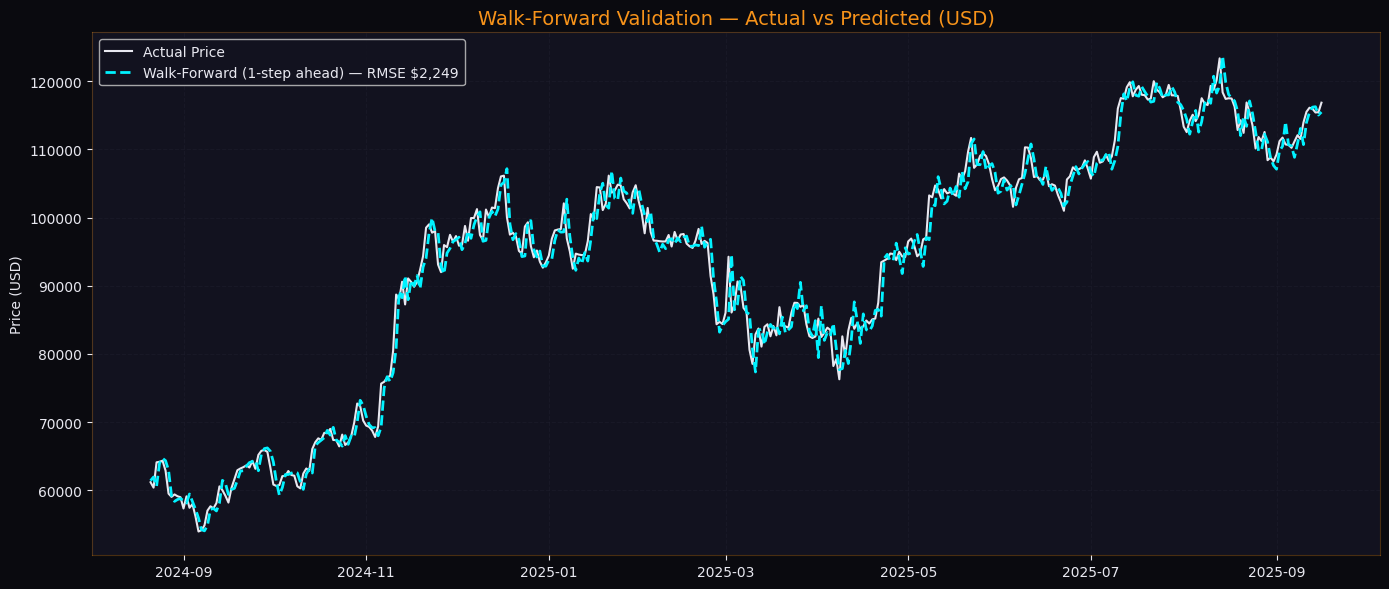

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(wf_df['ds'], wf_df['actual'],
        color='#e8e8f0', linewidth=1.5, label='Actual Price')
ax.plot(wf_df['ds'], wf_df['forecast'],
        color='#00f2ff', linewidth=2, linestyle='--',
        label=f'Walk-Forward (1-step ahead) — RMSE ${wf_rmse:,.0f}')
ax.set_title('Walk-Forward Validation — Actual vs Predicted (USD)', fontsize=14, color='#f7931a')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## Key Insights on Forecast Evaluation

### 1. Walk-forward validation is optimistic
- Uses the actual value at time **T** to predict **T+1**
- Introduces **look-ahead bias**
- Leads to **overestimation of model performance**

---

### 2. Static forecasting reflects real-world conditions
- Future values are **unknown**
- Predictions rely only on **past observed data**
- Provides the **true measure of model accuracy**

---

### 3. Error accumulation is unavoidable
- Multi-step forecasting is **recursive**
- Each prediction depends on previous predictions
- Small errors **compound over time** (*error propagation*)

---

### 4. Large gap in MAPE confirms this effect
- **Dynamic MAPE ≈ 1.83%** → optimistic, biased  
- **Static MAPE ≈ 23.11%** → realistic performance  

---

### 5. Loss of correction mechanism
- Walk-forward allows **continuous correction** using actual values  
- Static forecasting has **no feedback loop**  
- Results in **prediction drift over time**

---

### 6. Autocorrelated remainder is critical
- MSTL remainder shows strong **temporal dependence**
- Without real observations, this structure **cannot be leveraged effectively**

---

### 7. Model suitability
- Performs well for **one-step-ahead forecasting**
- Accuracy **degrades significantly** for multi-step horizons

---

